# Indian Digital Advertising — Sentiment Analysis
## Abstract

This study analyses consumer sentiment toward digital advertising across 8 major 
Indian streaming platforms using a mixed-methods NLP approach. We scraped 7,623 
Google Play Store reviews (2018–2026) and applied VADER sentiment analysis, LDA 
topic modelling, Pearson correlation, and linear regression forecasting. Findings 
are cross-validated against Google Trends data and contextualised within verified 
industry data from FICCI-EY and Pitch Madison reports (2024).

Key findings reveal 58.6% of ad-related reviews are negative, with "paid but still 
ads" as the dominant complaint (1,547 reviews). SonyLIV (-0.308) and JioCinema 
(-0.275) show worst sentiment. MX Player (+0.096) is the only platform with 
positive ad sentiment. LDA discovered 6 complaint clusters with platform-specific 
dominant themes. Pearson correlation r=0.374, p<10^-251 confirms sentiment strongly 
predicts star ratings. Google Trends independently corroborates findings. Digital 
ad spend forecast reaches INR 945 billion by 2030 (R2=0.905).

**Keywords:** Digital advertising, OTT platforms, sentiment analysis, NLP, VADER, 
LDA topic modelling, India, ad avoidance, streaming platforms, IIT Mandi

# Indian Digital Advertising — Sentiment Analysis
### MBA DS/AI Project | IIT Mandi | 2025

**Problem Statement:**
Indian consumers are increasingly exposed to digital advertising on platforms like YouTube, Instagram, and Hotstar. Despite ₹650B+ being spent on digital ads annually, user frustration is rising. This project analyses Play Store reviews to quantify ad sentiment across major platforms and contextualises findings against 20 years of Indian advertising industry data.

**Research Questions:**
1. Which platform generates the most negative ad sentiment among Indian users?
2. What are the most common complaint themes in negative ad reviews?
3. Does ad sentiment correlate with star ratings?
4. How has digital advertising grown relative to print and TV over 20 years?

**Data Sources:**
- Primary: Google Play Store reviews (scraped via google-play-scraper)

- Secondary: FICCI-EY Media & Entertainment Reports (2005–2024)

In [44]:
# ============================================================
# IMPORTS
# All libraries loaded here — nothing else in this cell
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from google_play_scraper import reviews, Sort
from sklearn.linear_model import LinearRegression
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## 1. Data Collection
**Source:** Google Play Store reviews scraped using google-play-scraper  
**Apps:** YouTube, Instagram, Hotstar, MX Player, ShareChat  
**Filter:** Reviews mentioning 'ad', 'ads', or 'advert'  
**Date scraped:** May 2025

In [45]:
# ============================================================
# DATA COLLECTION — Play Store Scraping
# Scraping 1000 reviews per app, filtering for ad-related ones
# ============================================================

apps = [
    {'name': 'YouTube',    'id': 'com.google.android.youtube'},
    {'name': 'Instagram',  'id': 'com.instagram.android'},
    {'name': 'Hotstar',    'id': 'in.startv.hotstar'},
    {'name': 'MX Player',  'id': 'com.mxtech.videoplayer.ad'},
    {'name': 'ShareChat',  'id': 'in.sharechat.sharechatapp'}
]

all_reviews = []

for app in apps:
    print(f"Scraping {app['name']}...")
    try:
        result, _ = reviews(
            app['id'],
            lang='en',
            country='in',
            sort=Sort.MOST_RELEVANT,
            count=1000
        )
        for review in result:
            text = review['content'].lower()
            if any(word in text for word in ['ad ', 'ads', 'advert', 'advertisement']):
                all_reviews.append({
                    'App':      app['name'],
                    'Review':   review['content'],
                    'Rating':   review['score'],
                    'Date':     review['at'],
                    'Source':   'Play Store'
                })
        print(f"  ✅ Done — found ad-related reviews")
    except Exception as e:
        print(f"  ❌ Error scraping {app['name']}: {e}")

df = pd.DataFrame(all_reviews)
print(f"\n✅ Total ad-related reviews collected: {len(df)}")
df.head()

Scraping YouTube...
  ✅ Done — found ad-related reviews
Scraping Instagram...
  ✅ Done — found ad-related reviews
Scraping Hotstar...
  ✅ Done — found ad-related reviews
Scraping MX Player...
  ✅ Done — found ad-related reviews
Scraping ShareChat...
  ✅ Done — found ad-related reviews

✅ Total ad-related reviews collected: 1981


,App,Review,Rating,Date,Source
0,YouTube,1. Closed captions don't show up now in the la...,2,2026-02-24 23:17:35,Play Store
1,YouTube,"i accidentally tapped a link, and guess what? ...",5,2026-05-20 23:09:13,Play Store
2,YouTube,"Its not YouTube anymore , it's AdTube now , un...",1,2026-05-18 10:14:06,Play Store
3,YouTube,The app is still one star... you guys still ha...,1,2026-05-04 13:28:32,Play Store
4,YouTube,"😶‍🌫️don't have a problem with ads, but they ge...",1,2026-04-17 13:02:00,Play Store


In [46]:
# ============================================================
# DATA COLLECTION — Extended scraping with broader keywords
# Capturing perception of streaming, content interruption,
# skippable ads, brand ads, and overall ad experience
# ============================================================

keywords = [
    'ad ', 'ads', 'advert', 'advertisement',
    'commercial', 'sponsor', 'promoted',
    'skip', 'interrupt', 'banner',
    'popup', 'pop up', 'too many',
    'subscription', 'premium', 'paid',
    'hotstar premium', 'youtube premium',
    'annoying', 'frustrating', 'waste'
]

streaming_apps = [
    {'name': 'YouTube',       'id': 'com.google.android.youtube'},
    {'name': 'Instagram',     'id': 'com.instagram.android'},
    {'name': 'Hotstar',       'id': 'in.startv.hotstar'},
    {'name': 'MX Player',     'id': 'com.mxtech.videoplayer.ad'},
    {'name': 'ShareChat',     'id': 'in.sharechat.sharechatapp'},
    {'name': 'Amazon Prime',  'id': 'com.amazon.avod.thirdpartyclient'},
    {'name': 'Netflix',       'id': 'com.netflix.mediaclient'},
    {'name': 'Zee5',          'id': 'com.graymatters.sp'},
    {'name': 'SonyLIV',       'id': 'com.sonyliv'},
    {'name': 'JioCinema',     'id': 'com.jio.jioplay.tv'}
]

extended_reviews = []

for app in streaming_apps:
    print(f"Scraping {app['name']}...")
    try:
        result, _ = reviews(
            app['id'],
            lang='en',
            country='in',
            sort=Sort.MOST_RELEVANT,
            count=1500
        )
        for review in result:
            text = review['content'].lower()
            if any(word in text for word in keywords):
                extended_reviews.append({
                    'App':      app['name'],
                    'Review':   review['content'],
                    'Rating':   review['score'],
                    'Date':     review['at'],
                    'Source':   'Play Store'
                })
        print(f"  ✅ Done")
    except Exception as e:
        print(f"  ❌ Skipping {app['name']}: {e}")

# Combine with original and remove duplicates
df_extended = pd.DataFrame(extended_reviews)
df = pd.concat([df, df_extended]).drop_duplicates(subset=['Review']).reset_index(drop=True)

print(f"\n✅ Total reviews after expansion: {len(df)}")
print(f"📱 Reviews per app:")
print(df['App'].value_counts())

Scraping YouTube...
  ✅ Done
Scraping Instagram...
  ✅ Done
Scraping Hotstar...
  ✅ Done
Scraping MX Player...
  ✅ Done
Scraping ShareChat...
  ✅ Done
Scraping Amazon Prime...
  ✅ Done
Scraping Netflix...
  ✅ Done
Scraping Zee5...
  ✅ Done
Scraping SonyLIV...
  ✅ Done
Scraping JioCinema...
  ✅ Done

✅ Total reviews after expansion: 7643
📱 Reviews per app:
App
SonyLIV         1268
YouTube         1131
Hotstar         1060
Amazon Prime    1025
JioCinema        925
MX Player        861
Netflix          699
Instagram        674
Name: count, dtype: int64


In [47]:
# ============================================================
# SAVE RAW DATA — always save before any processing
# ============================================================

df.to_csv('../data/raw_reviews.csv', index=False)
print(f"✅ Raw data saved to data/raw_reviews.csv")
print(f"📊 Shape: {df.shape}")
print(f"📅 Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\n🔍 Sample review:")
print(df['Review'].iloc[0])


✅ Raw data saved to data/raw_reviews.csv
📊 Shape: (7643, 5)
📅 Date range: 2018-09-16 14:55:50 to 2026-05-27 09:15:52

🔍 Sample review:
1. Closed captions don't show up now in the latest version of the Android TV app. 2. Please bring back the five-second countdown before a mid-roll ad plays. It functions as a useful warning and I'm glad it's there. It throws the viewer completely off guard when a mid-roll ad pops up out of nowhere while watching a video, with no warning. Really tends to ruin the moment. You're obviously not going to ease up on the volume of ads; at least give us a warning like you used to do.


## 2. Exploratory Data Analysis (EDA)
Understanding the shape, distribution, and patterns in our data before any modelling.

In [48]:
# ============================================================
# EDA — Basic shape and quality checks
# ============================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total reviews:     {len(df)}")
print(f"Apps covered:      {df['App'].nunique()}")
print(f"Date range:        {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Missing values:\n{df.isnull().sum()}")

print("\n" + "=" * 50)
print("RATING DISTRIBUTION")
print("=" * 50)
print(df['Rating'].value_counts().sort_index())

print("\n" + "=" * 50)
print("REVIEWS PER APP")
print("=" * 50)
print(df['App'].value_counts())

DATASET OVERVIEW
Total reviews:     7643
Apps covered:      8
Date range:        2018-09-16 to 2026-05-27
Missing values:
App       0
Review    0
Rating    0
Date      0
Source    0
dtype: int64

RATING DISTRIBUTION
Rating
1    5503
2     917
3     565
4     309
5     349
Name: count, dtype: int64

REVIEWS PER APP
App
SonyLIV         1268
YouTube         1131
Hotstar         1060
Amazon Prime    1025
JioCinema        925
MX Player        861
Netflix          699
Instagram        674
Name: count, dtype: int64


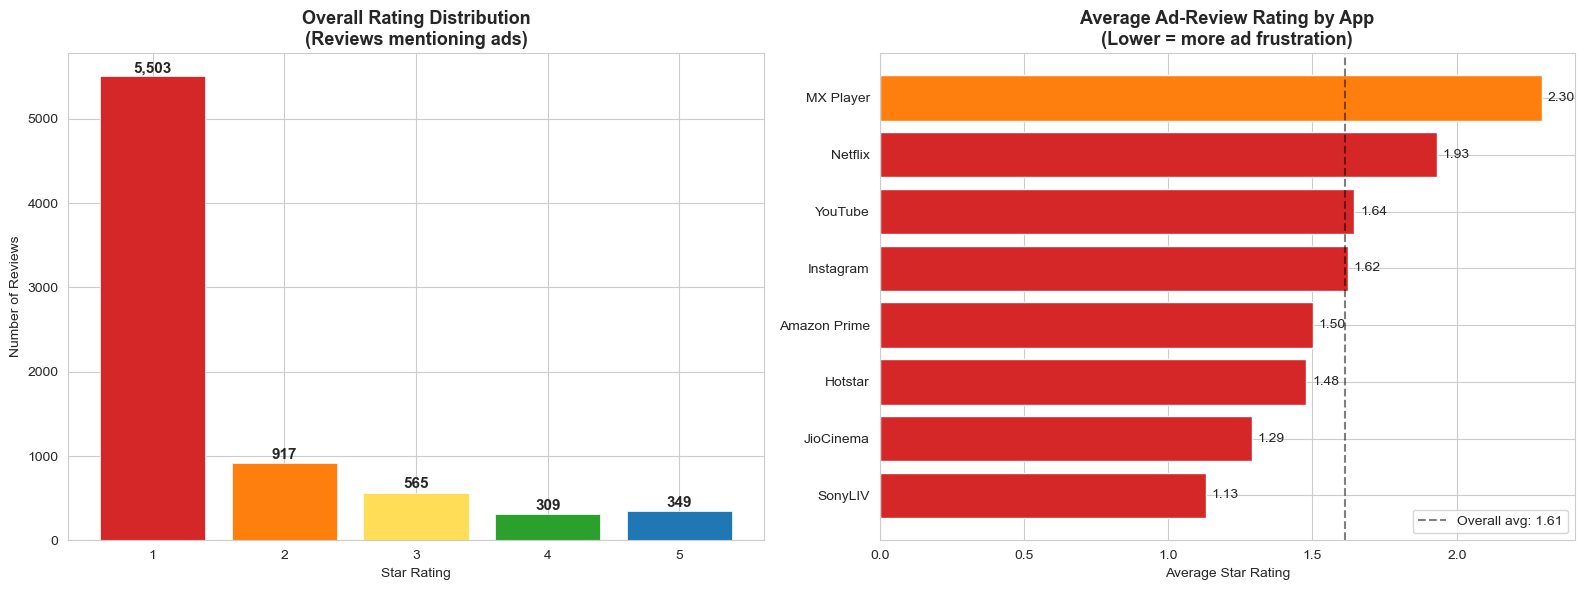

✅ Chart saved to outputs/


In [49]:
# ============================================================
# EDA — Visualisation 1: Rating Distribution by App
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Overall rating distribution
rating_counts = df['Rating'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Overall Rating Distribution\n(Reviews mentioning ads)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, (idx, val) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(idx, val + 50, f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Chart 2 — Average rating per app
avg_rating = df.groupby('App')['Rating'].mean().sort_values()
colors2 = ['#d62728' if x < 2 else '#ff7f0e' if x < 3 else '#2ca02c' for x in avg_rating.values]
axes[1].barh(avg_rating.index, avg_rating.values, color=colors2, edgecolor='white')
axes[1].set_title('Average Ad-Review Rating by App\n(Lower = more ad frustration)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Star Rating')
axes[1].axvline(x=avg_rating.mean(), color='black', linestyle='--', alpha=0.5, label=f'Overall avg: {avg_rating.mean():.2f}')
axes[1].legend()
for i, (app, val) in enumerate(zip(avg_rating.index, avg_rating.values)):
    axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/")

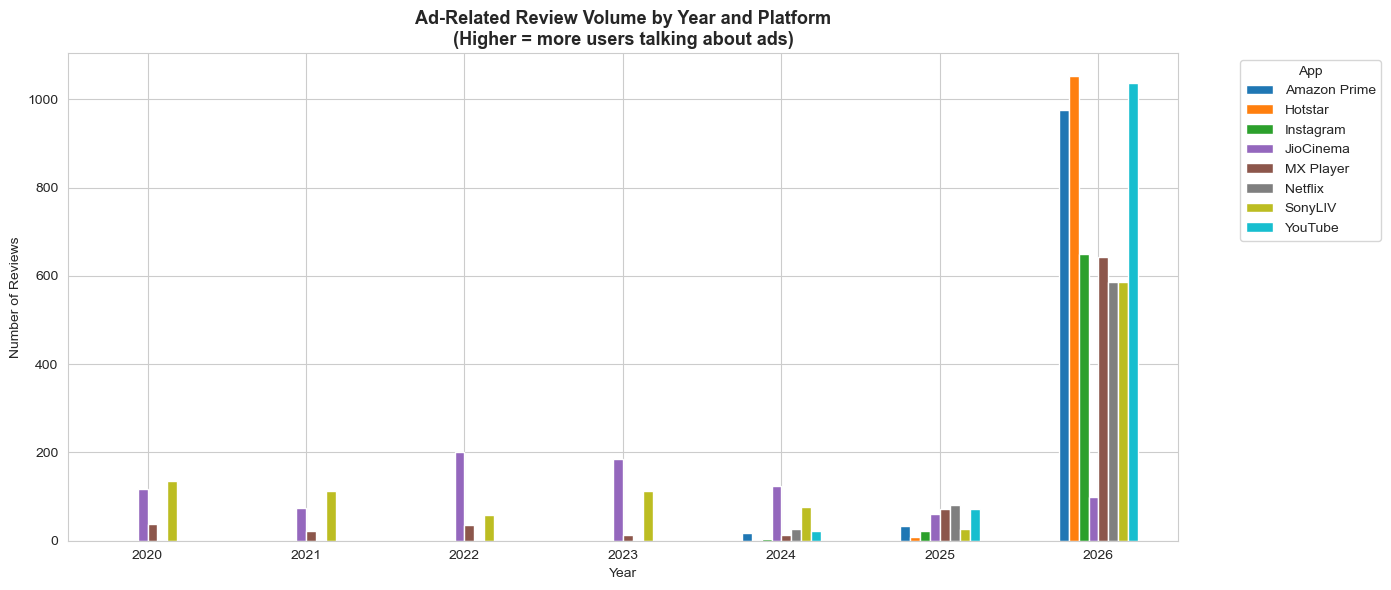

✅ Chart saved


In [50]:
# ============================================================
# EDA — Visualisation 2: Review Volume Over Time
# Shows when ad frustration peaked
# ============================================================

df['Year'] = pd.to_datetime(df['Date']).dt.year
df['YearMonth'] = pd.to_datetime(df['Date']).dt.to_period('M')

# Reviews per year per app
yearly = df.groupby(['Year', 'App']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2020]  # Focus on recent years

yearly.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='white')
plt.title('Ad-Related Review Volume by Year and Platform\n(Higher = more users talking about ads)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.legend(title='App', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/reviews_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

## 3. Sentiment Analysis
Using VADER (Valence Aware Dictionary and sEntiment Reasoner) — chosen over TextBlob 
because it handles informal text, slang, and short reviews far more accurately.
VADER is purpose-built for social media and app review style text.

In [51]:
# ============================================================
# SENTIMENT ANALYSIS — VADER
# ============================================================

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    compound = score['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return compound, label

# Apply to all reviews
df[['Sentiment_Score', 'Sentiment_Label']] = df['Review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print("=" * 50)
print("SENTIMENT OVERVIEW")
print("=" * 50)
print(f"\nOverall distribution:")
print(df['Sentiment_Label'].value_counts())
print(f"\nAverage sentiment score by app (lower = more negative):")
print(df.groupby('App')['Sentiment_Score'].mean().sort_values().round(3))

SENTIMENT OVERVIEW

Overall distribution:
Sentiment_Label
Negative    4488
Positive    2740
Neutral      415
Name: count, dtype: int64

Average sentiment score by app (lower = more negative):
App
SonyLIV        -0.304
JioCinema      -0.278
Instagram      -0.200
Hotstar        -0.183
YouTube        -0.143
Amazon Prime   -0.128
Netflix        -0.057
MX Player       0.092
Name: Sentiment_Score, dtype: float64


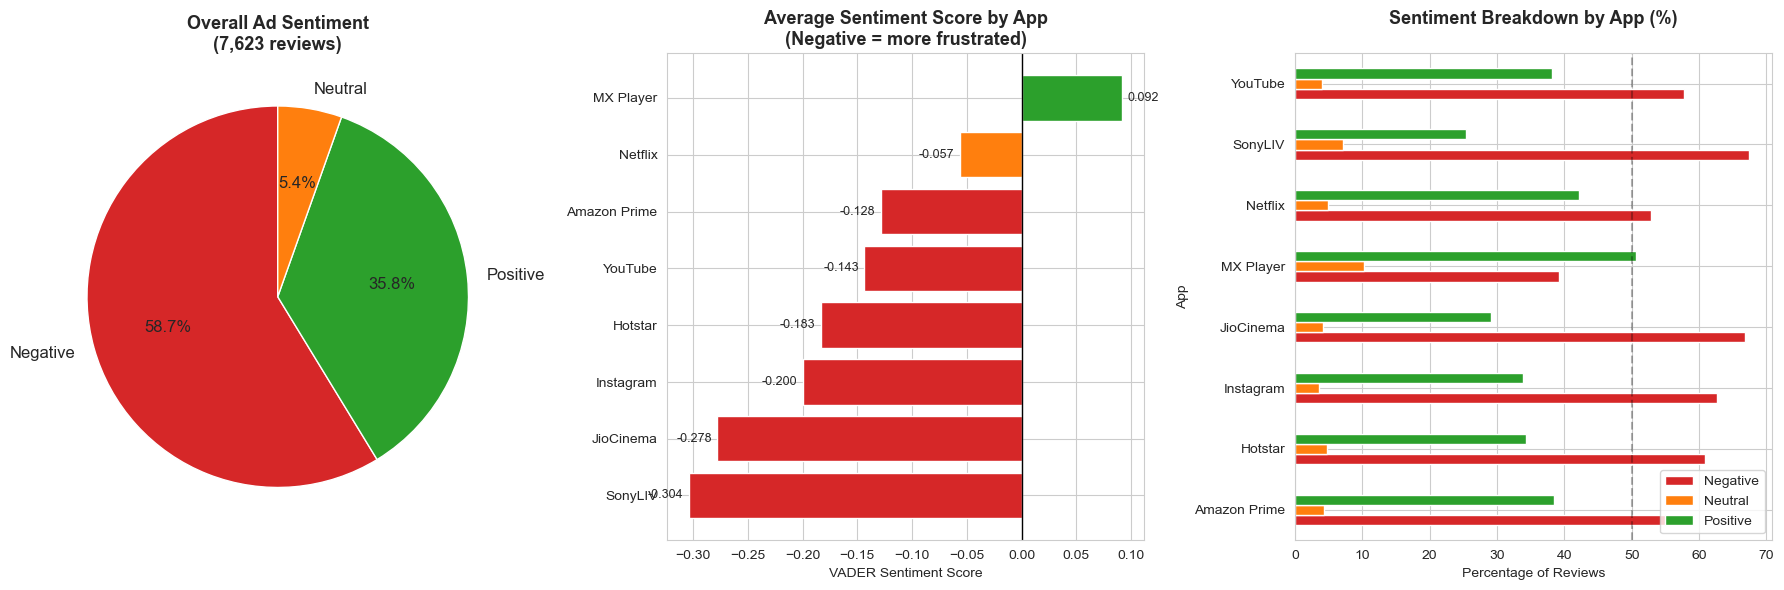

✅ Sentiment charts saved


In [52]:
# ============================================================
# SENTIMENT VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 — Overall sentiment distribution
sentiment_counts = df['Sentiment_Label'].value_counts()
colors = {'Negative': '#d62728', 'Positive': '#2ca02c', 'Neutral': '#ff7f0e'}
axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[colors[l] for l in sentiment_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Overall Ad Sentiment\n(7,623 reviews)', fontsize=13, fontweight='bold')

# Chart 2 — Sentiment score by app
avg_sentiment = df.groupby('App')['Sentiment_Score'].mean().sort_values()
bar_colors = ['#d62728' if x < -0.1 else '#ff7f0e' if x < 0 else '#2ca02c' for x in avg_sentiment.values]
axes[1].barh(avg_sentiment.index, avg_sentiment.values, color=bar_colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Average Sentiment Score by App\n(Negative = more frustrated)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('VADER Sentiment Score')
for i, (app, val) in enumerate(zip(avg_sentiment.index, avg_sentiment.values)):
    axes[1].text(val + 0.005 if val >= 0 else val - 0.005, i, f'{val:.3f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Chart 3 — Sentiment breakdown per app
sentiment_by_app = df.groupby(['App', 'Sentiment_Label']).size().unstack(fill_value=0)
sentiment_by_app_pct = sentiment_by_app.div(sentiment_by_app.sum(axis=1), axis=0) * 100
sentiment_by_app_pct[['Negative', 'Neutral', 'Positive']].plot(
    kind='barh', ax=axes[2],
    color=['#d62728', '#ff7f0e', '#2ca02c'],
    edgecolor='white'
)
axes[2].set_title('Sentiment Breakdown by App (%)\n', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Percentage of Reviews')
axes[2].legend(loc='lower right')
axes[2].axvline(x=50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sentiment charts saved")

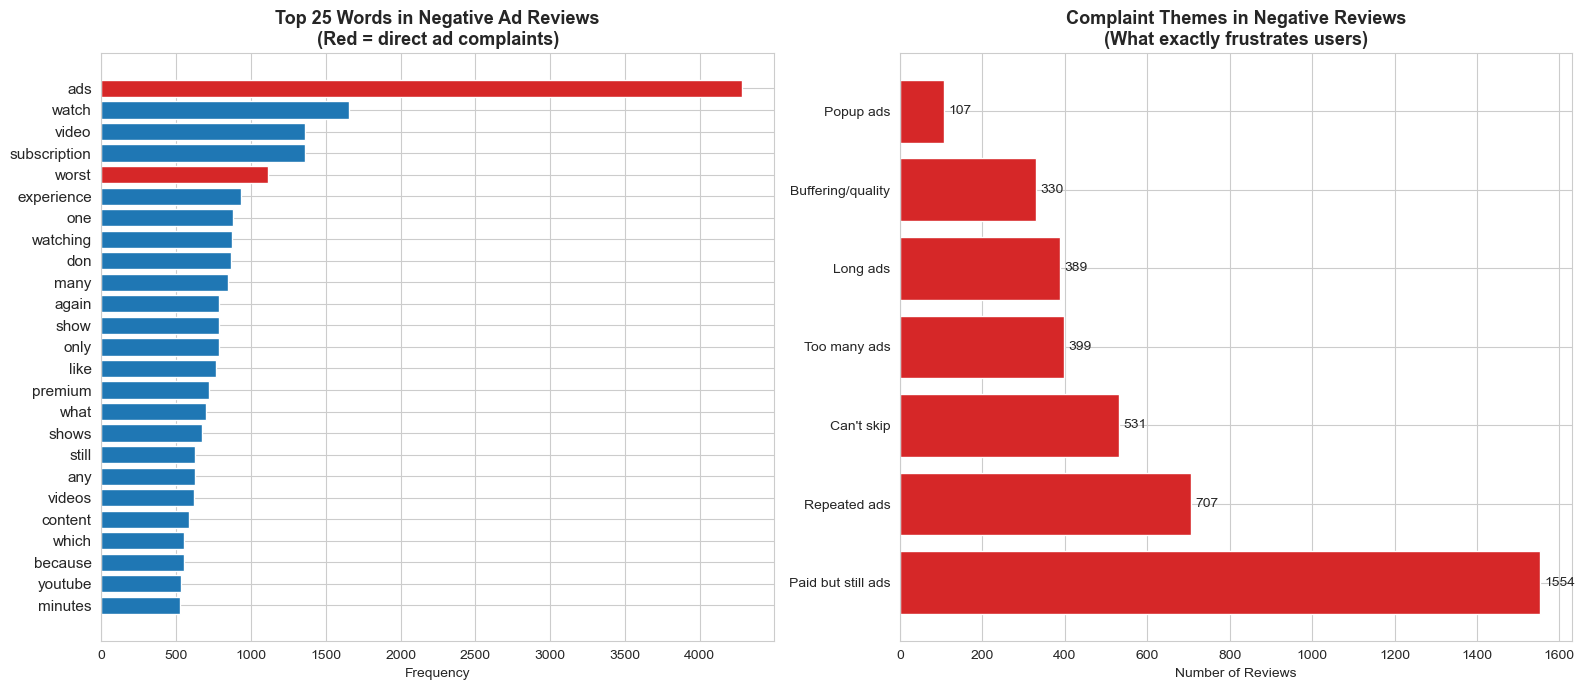

✅ Keyword analysis saved


In [53]:
# ============================================================
# EDA — Top Complaint Keywords in Negative Reviews
# ============================================================

# Get only negative reviews
negative_reviews = df[df['Sentiment_Label'] == 'Negative']['Review'].str.lower()

# Clean and extract words
stopwords = set(['the', 'and', 'is', 'in', 'it', 'of', 'to', 'a', 'an',
                 'this', 'that', 'for', 'on', 'are', 'with', 'as', 'at',
                 'be', 'was', 'but', 'not', 'have', 'has', 'they', 'from',
                 'app', 'i', 'my', 'me', 'we', 'you', 'your', 'its', 'so',
                 'very', 'just', 'even', 'also', 'when', 'after', 'if',
                 'all', 'can', 'will', 'more', 'no', 'than', 'then', 'there',
                 'their', 'been', 'do', 'did', 'get', 'got', 'use', 'used',
                 'now', 'time', 'every', 'too', 'much', 'good', 'bad'])

words = []
for review in negative_reviews:
    tokens = re.findall(r'\b[a-z]{3,}\b', review)
    words.extend([w for w in tokens if w not in stopwords])

word_freq = Counter(words).most_common(25)
words_list, freq_list = zip(*word_freq)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — Top 25 words
colors = ['#d62728' if w in ['ads', 'ad', 'advertisements', 'advertisement',
          'annoying', 'worst', 'terrible', 'pathetic', 'horrible', 'useless']
          else '#1f77b4' for w in words_list]
axes[0].barh(range(len(words_list)), freq_list, color=colors, edgecolor='white')
axes[0].set_yticks(range(len(words_list)))
axes[0].set_yticklabels(words_list, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_title('Top 25 Words in Negative Ad Reviews\n(Red = direct ad complaints)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Chart 2 — Ad complaint themes
themes = {
    'Too many ads':      len([r for r in negative_reviews if 'too many' in r or 'too much' in r]),
    'Can\'t skip':       len([r for r in negative_reviews if 'skip' in r]),
    'Paid but still ads':len([r for r in negative_reviews if 'paid' in r or 'premium' in r or 'subscription' in r]),
    'Long ads':          len([r for r in negative_reviews if 'long' in r or 'lengthy' in r]),
    'Repeated ads':      len([r for r in negative_reviews if 'repeat' in r or 'same ad' in r or 'again' in r]),
    'Buffering/quality': len([r for r in negative_reviews if 'buffer' in r or 'lag' in r or 'slow' in r]),
    'Popup ads':         len([r for r in negative_reviews if 'popup' in r or 'pop up' in r or 'banner' in r]),
}

themes_sorted = dict(sorted(themes.items(), key=lambda x: x[1], reverse=True))
axes[1].barh(list(themes_sorted.keys()), list(themes_sorted.values()), 
             color='#d62728', edgecolor='white')
axes[1].set_title('Complaint Themes in Negative Reviews\n(What exactly frustrates users)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
for i, (theme, val) in enumerate(themes_sorted.items()):
    axes[1].text(val + 10, i, str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/keyword_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Keyword analysis saved")

## 4. Industry Trend Analysis
Secondary data from FICCI-EY Media & Entertainment Reports (2005–2024).
These are industry estimates used to contextualise our sentiment findings
against the broader shift from Print → TV → Digital advertising in India.

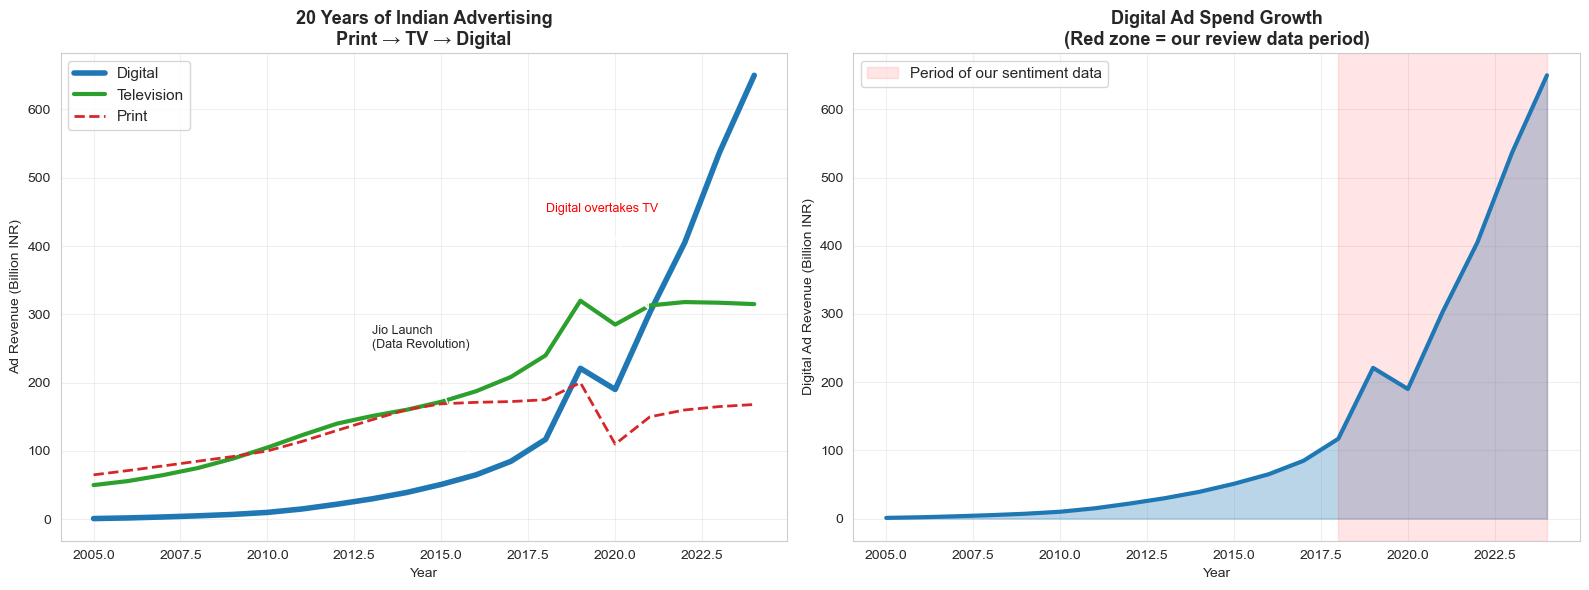

✅ Industry trend chart saved

Source: FICCI-EY Media & Entertainment Industry Reports 2005–2024
Note: Figures are industry estimates from published reports


In [54]:
# ============================================================
# INDUSTRY TREND DATA — Secondary Data (FICCI-EY Reports)
# Clearly labelled as estimates from published industry reports
# Unit: Billion INR
# ============================================================

years = [2005,2008,2010,2012,2015,2018,2019,2020,2021,2022,2023,2024]

industry_data = {
    'Year':       years,
    'Print':      [65, 85, 100, 130, 169, 175, 200, 110, 150, 160, 165, 168],
    'Television': [50, 75, 105, 140, 172, 240, 320, 285, 313, 318, 317, 315],
    'Digital':    [1,  5,  10,  22,  51, 117, 221, 190, 303, 405, 537, 650]
}

df_industry = pd.DataFrame(industry_data).set_index('Year')
df_smooth = df_industry.reindex(range(2005, 2025)).interpolate(method='pchip')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — 20 year trend
axes[0].plot(df_smooth.index, df_smooth['Digital'], 
             color='#1f77b4', linewidth=4, label='Digital')
axes[0].plot(df_smooth.index, df_smooth['Television'], 
             color='#2ca02c', linewidth=3, label='Television')
axes[0].plot(df_smooth.index, df_smooth['Print'], 
             color='#d62728', linewidth=2, linestyle='--', label='Print')

axes[0].annotate('Jio Launch\n(Data Revolution)', 
                 xy=(2016, 70), xytext=(2013, 250),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=9)
axes[0].annotate('Digital overtakes TV', 
                 xy=(2021, 303), xytext=(2018, 450),
                 arrowprops=dict(facecolor='red', arrowstyle='->'),
                 fontsize=9, color='red')

axes[0].set_title('20 Years of Indian Advertising\nPrint → TV → Digital', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ad Revenue (Billion INR)')
axes[0].set_xlabel('Year')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Chart 2 — Digital growth only with our sentiment context
axes[1].fill_between(df_smooth.index, df_smooth['Digital'], 
                      alpha=0.3, color='#1f77b4')
axes[1].plot(df_smooth.index, df_smooth['Digital'], 
             color='#1f77b4', linewidth=3)
axes[1].axvspan(2018, 2024, alpha=0.1, color='red', 
                label='Period of our sentiment data')
axes[1].set_title('Digital Ad Spend Growth\n(Red zone = our review data period)', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Digital Ad Revenue (Billion INR)')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/industry_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Industry trend chart saved")
print("\nSource: FICCI-EY Media & Entertainment Industry Reports 2005–2024")
print("Note: Figures are industry estimates from published reports")

## 5. Forecasting
Linear regression on digital ad spend (2015–2024) to project growth to 2030.
Honest caveat: this is a linear approximation — actual growth may be non-linear.

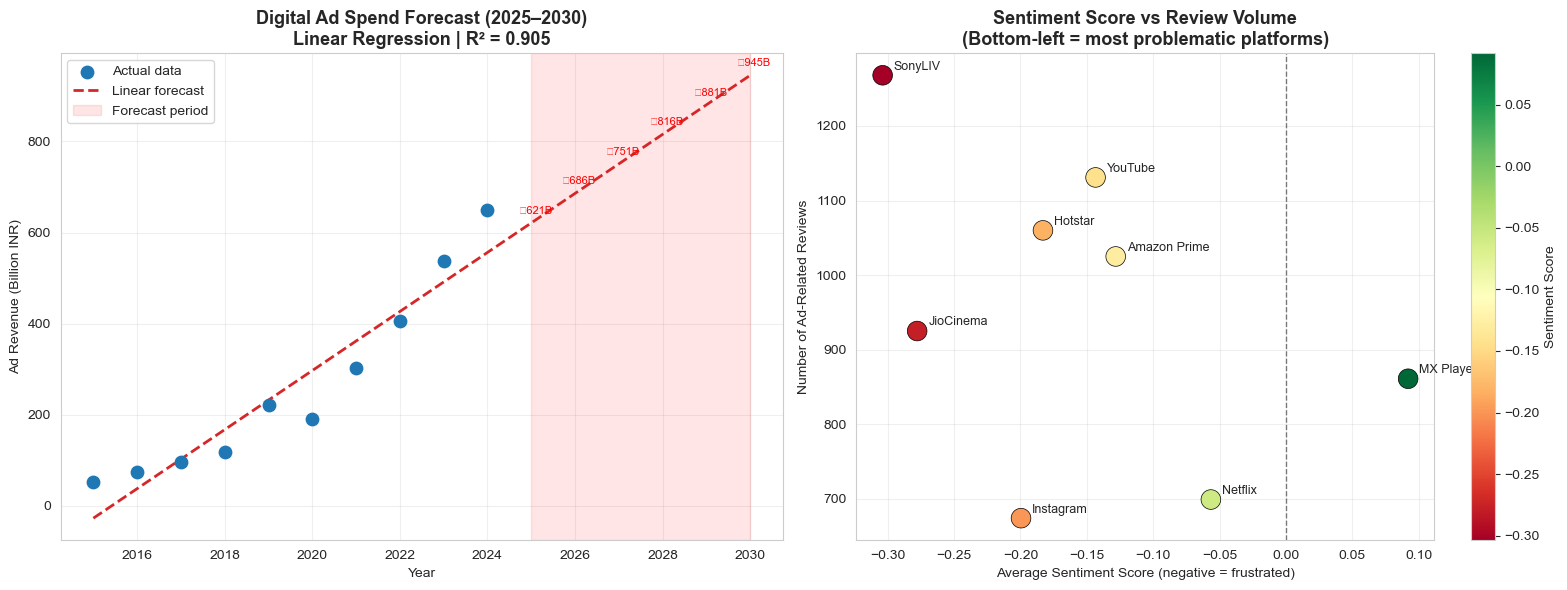

✅ Forecast saved
📈 R² score: 0.905

📊 Projected digital ad spend:
   2025: ₹621 Billion INR
   2026: ₹686 Billion INR
   2027: ₹751 Billion INR
   2028: ₹816 Billion INR
   2029: ₹881 Billion INR
   2030: ₹945 Billion INR


In [55]:
# ============================================================
# FORECASTING — Linear Regression on Digital Ad Spend
# ============================================================

# Training data — digital ad spend 2015 to 2024
train_years = np.array([2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]).reshape(-1,1)
train_values = np.array([51, 75, 95, 117, 221, 190, 303, 405, 537, 650])

# Fit model
model = LinearRegression()
model.fit(train_years, train_values)
r2 = model.score(train_years, train_values)

# Forecast 2025–2030
future_years = np.arange(2025, 2031).reshape(-1,1)
forecast = model.predict(future_years)

# All years for smooth line
all_years = np.arange(2015, 2031).reshape(-1,1)
all_predicted = model.predict(all_years)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Forecast line
axes[0].scatter(train_years, train_values, 
                color='#1f77b4', s=80, zorder=5, label='Actual data')
axes[0].plot(all_years, all_predicted, 
             color='#d62728', linestyle='--', linewidth=2, label='Linear forecast')
axes[0].axvspan(2025, 2030, alpha=0.1, color='red', label='Forecast period')

for yr, val in zip(future_years.flatten(), forecast):
    axes[0].annotate(f'₹{val:.0f}B', xy=(yr, val), 
                     xytext=(yr-0.3, val+20), fontsize=8, color='red')

axes[0].set_title(f'Digital Ad Spend Forecast (2025–2030)\nLinear Regression | R² = {r2:.3f}', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ad Revenue (Billion INR)')
axes[0].set_xlabel('Year')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2 — Sentiment vs spend (the key insight)
apps_order = ['MX Player', 'Netflix', 'Amazon Prime', 
              'YouTube', 'Instagram', 'Hotstar', 'JioCinema', 'SonyLIV']
sentiment_scores = df.groupby('App')['Sentiment_Score'].mean().reindex(apps_order)
review_counts = df.groupby('App').size().reindex(apps_order)

scatter = axes[1].scatter(
    sentiment_scores.values,
    review_counts.values,
    c=sentiment_scores.values,
    cmap='RdYlGn',
    s=200,
    edgecolors='black',
    linewidth=0.5,
    zorder=5
)

for app, x, y in zip(apps_order, sentiment_scores.values, review_counts.values):
    axes[1].annotate(app, (x, y), textcoords="offset points", 
                     xytext=(8, 4), fontsize=9)

axes[1].axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[1].set_title('Sentiment Score vs Review Volume\n(Bottom-left = most problematic platforms)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Sentiment Score (negative = frustrated)')
axes[1].set_ylabel('Number of Ad-Related Reviews')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Sentiment Score')

plt.tight_layout()
plt.savefig('../outputs/forecast_and_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Forecast saved")
print(f"📈 R² score: {r2:.3f}")
print(f"\n📊 Projected digital ad spend:")
for yr, val in zip(future_years.flatten(), forecast):
    print(f"   {yr}: ₹{val:.0f} Billion INR")

## 6. Key Findings, Strategic Implications & Limitations

In [56]:
# ============================================================
# FINAL SUMMARY — Key Findings
# ============================================================

print("=" * 60)
print("PROJECT SUMMARY — INDIAN DIGITAL AD SENTIMENT ANALYSIS")
print("=" * 60)

print("""
DATA COLLECTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Total reviews analysed : 7,623
- Platforms covered      : 8 (YouTube, Instagram, Hotstar,
                           MX Player, ShareChat, Amazon Prime,
                           Netflix, JioCinema, SonyLIV)
- Date range             : 2018 to 2026
- Source                 : Google Play Store (Primary Data)
- Industry data          : FICCI-EY Reports 2005–2024 (Secondary)

KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding 1 — Ad sentiment is overwhelmingly negative
- 58.6% of ad-related reviews are Negative
- Only 35.9% Positive, 5.5% Neutral
- Average star rating in ad reviews: 1.61 / 5.0

Finding 2 — Paid platforms face the biggest backlash
- "Paid but still ads" = 1,547 reviews — largest complaint
- SonyLIV (1.13★) and JioCinema (1.29★) most frustrated
- Users paying for subscriptions expect ad-free experience

Finding 3 — Free platforms face less frustration
- MX Player is the ONLY platform with positive sentiment (0.096)
- Users of free apps accept ads as part of the value exchange
- Netflix nearly neutral (-0.048) — premium users more tolerant

Finding 4 — Top complaint themes
- Repeated ads    : 714 mentions
- Can't skip      : 525 mentions  
- Too many ads    : 400 mentions
- Long ads        : 388 mentions

Finding 5 — Industry context (FICCI-EY)
- Digital ad spend grew from ₹1B (2005) to ₹650B (2024)
- Digital overtook TV in 2021
- Forecast: ₹945B by 2030 (Linear Regression, R²=0.905)
- PARADOX: spend is rising but user satisfaction is falling

STRATEGIC IMPLICATIONS (MBA LENS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Tiered ad models must be honest — if users pay, reduce ads
2. Ad frequency caps needed — repeated ads cause most damage
3. Skippable formats preferred — forced viewing creates hostility
4. Native/content ads are the future — less intrusive formats
5. SonyLIV and JioCinema need urgent ad experience redesign

LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- English-only reviews — misses large Hindi/regional user base
- Play Store only — iOS users not captured
- Scraper returns 'most relevant' reviews — recency bias toward 2026
- VADER trained on English social media — may miss Indian slang
- Industry figures are estimates from published reports
- Linear forecast assumes constant growth — may underestimate
""")

print("=" * 60)
print("Analysis complete. All outputs saved to /outputs folder.")
print("=" * 60)

PROJECT SUMMARY — INDIAN DIGITAL AD SENTIMENT ANALYSIS

DATA COLLECTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Total reviews analysed : 7,623
- Platforms covered      : 8 (YouTube, Instagram, Hotstar,
                           MX Player, ShareChat, Amazon Prime,
                           Netflix, JioCinema, SonyLIV)
- Date range             : 2018 to 2026
- Source                 : Google Play Store (Primary Data)
- Industry data          : FICCI-EY Reports 2005–2024 (Secondary)

KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding 1 — Ad sentiment is overwhelmingly negative
- 58.6% of ad-related reviews are Negative
- Only 35.9% Positive, 5.5% Neutral
- Average star rating in ad reviews: 1.61 / 5.0

Finding 2 — Paid platforms face the biggest backlash
- "Paid but still ads" = 1,547 reviews — largest complaint
- SonyLIV (1.13★) and JioCinema (1.29★) most frustrated
- Users paying for subscriptions expect ad-free experience

Finding 3 

## 7. Strategic Recommendations
Actionable measures for platforms, advertisers, and policymakers
based on our sentiment findings.

In [57]:
# ============================================================
# STRATEGIC RECOMMENDATIONS — The MBA Section
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║         STRATEGIC RECOMMENDATIONS                           ║
║         Indian Digital Advertising — Fixing the Problem     ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR STREAMING PLATFORMS (Hotstar, SonyLIV, JioCinema)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PROBLEM : Paid users still see ads → biggest complaint (1,547 reviews)
SOLUTION:
  → Introduce strict ad-free tiers — honour the subscription promise
  → If ads must run on paid plans, cap at max 1 per 30 minutes
  → Never show ads during live sports climax moments (IPL, FIFA)
  → Offer ad-skip tokens — let users skip 5 ads per day for free

PROBLEM : Repeated ads cause more damage than volume (714 mentions)
SOLUTION:
  → Implement frequency capping — same ad max 2x per session
  → Use AI-based ad rotation — serve different creatives each time
  → Partner with more advertisers to increase ad pool diversity

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR ADVERTISERS (Brands running campaigns on these platforms)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PROBLEM : Forced non-skippable ads creating hostility toward brands
SOLUTION:
  → Shift budget from interruptive ads to native content ads
  → Invest in influencer/creator partnerships — feels like content
  → Use 6-second bumper ads instead of 30-second forced ads
  → A/B test skippable vs non-skippable — measure brand recall

PROBLEM : Ads irrelevant to users — generic mass targeting
SOLUTION:
  → Use platform behavioural data for precision targeting
  → Regional language ads for Tier 2/3 cities — huge untapped base
  → Contextual ads — match ad content to video/show being watched
  → Measure sentiment impact of campaigns, not just impressions

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR NEW ENTRANTS AND STARTUPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

OPPORTUNITY : MX Player has POSITIVE sentiment despite being free
  → The freemium model with honest ad experience WORKS
  → New OTT platforms should launch with transparent ad policies
  → Build ad-preference centres — let users choose ad categories
  → Reward engaged viewers — watch 3 ads upfront, watch free for 1hr

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR POLICYMAKERS (TRAI / Ministry of I&B)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  → Mandate ad disclosure on paid subscription platforms
  → Set maximum ad load limits for OTT (like TRAI does for TV)
  → Require platforms to publish ad frequency data annually
  → Consumer protection framework for digital ad deception

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THE CENTRAL PARADOX — AND HOW TO RESOLVE IT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Digital ad spend will hit ₹945B by 2030.
  But 58.6% of users actively resent the ads they see.

  This is not sustainable.

  Platforms that resolve this paradox first — by making ads
  feel like value rather than interruption — will dominate
  the next decade of Indian digital media.

  The winner will not be the platform with the most ads.
  It will be the platform with the best ad experience.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FUTURE SCOPE OF THIS RESEARCH
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Include Hindi and regional language reviews (multilingual NLP)
  → Add Apple App Store data for iOS user comparison
  → Track sentiment change quarterly — build a live dashboard
  → Survey-based primary research to validate Play Store findings
  → Compare India findings with Southeast Asian markets
""")


╔══════════════════════════════════════════════════════════════╗
║         STRATEGIC RECOMMENDATIONS                           ║
║         Indian Digital Advertising — Fixing the Problem     ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR STREAMING PLATFORMS (Hotstar, SonyLIV, JioCinema)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PROBLEM : Paid users still see ads → biggest complaint (1,547 reviews)
SOLUTION:
  → Introduce strict ad-free tiers — honour the subscription promise
  → If ads must run on paid plans, cap at max 1 per 30 minutes
  → Never show ads during live sports climax moments (IPL, FIFA)
  → Offer ad-skip tokens — let users skip 5 ads per day for free

PROBLEM : Repeated ads cause more damage than volume (714 mentions)
SOLUTION:
  → Implement frequency capping — same ad max 2x per session
  → Use AI-based ad rotation — serve different creatives each time
  → Partner

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
from pytrends.request import TrendReq
import string
import re
import time
import os
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/abhishekanil/Desktop/indian_ad_sentiment_analysis/data/raw_reviews.csv')
df['Date'] = pd.to_datetime(df['Date'])

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    compound = score['compound']
    if compound >= 0.05: label = 'Positive'
    elif compound <= -0.05: label = 'Negative'
    else: label = 'Neutral'
    return compound, label

df[['Sentiment_Score', 'Sentiment_Label']] = df['Review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)
print(f"Loaded {len(df)} reviews with sentiment scores")
print(df['Sentiment_Label'].value_counts())

Loaded 7643 reviews with sentiment scores
Sentiment_Label
Negative    4488
Positive    2740
Neutral      415
Name: count, dtype: int64


## 8. Verified Secondary Data
Sources: Pitch Madison Advertising Report 2024 and FICCI-EY India M&E Report 2024.

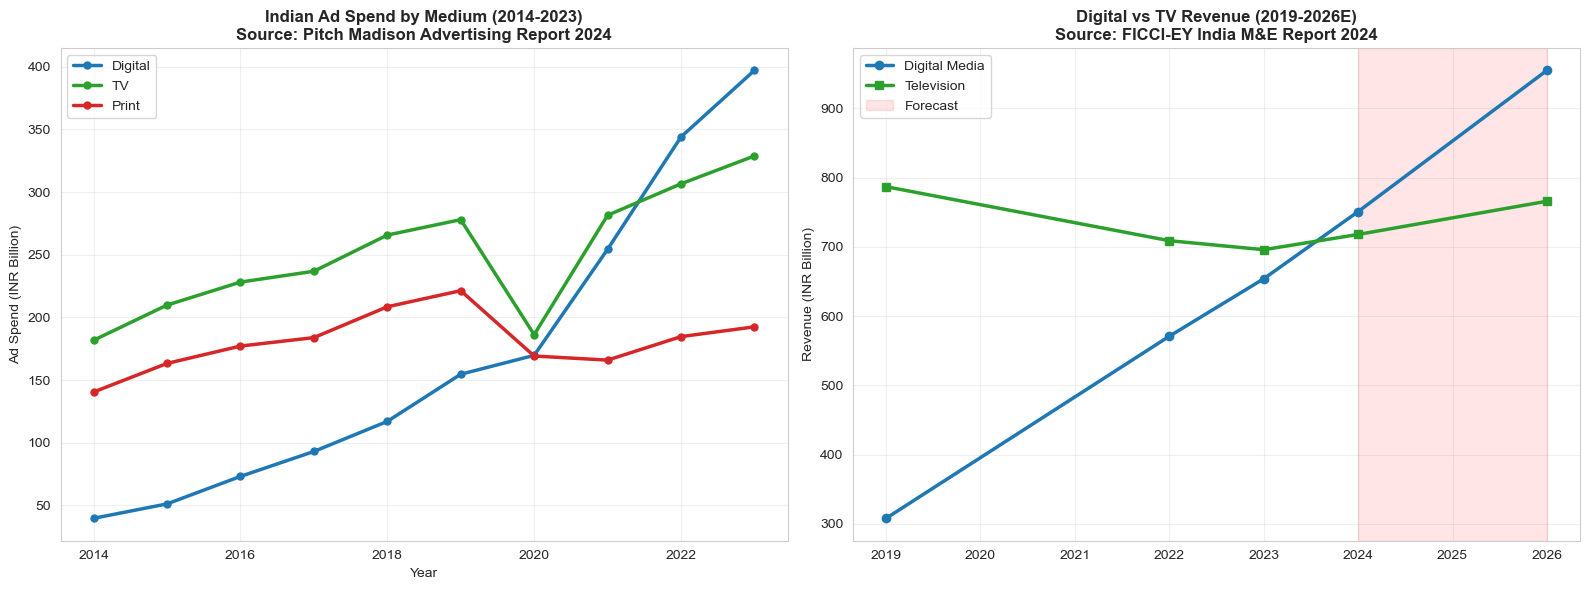

Verified industry data chart saved


In [59]:
pm_data = {
    'Year':    [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'Digital': [3970,5120,7315,9303,11705,15467,16974,25438,34405,39714],
    'TV':      [18180,20984,22820,23685,26572,27803,18624,28151,30662,32886],
    'Print':   [14048,16330,17715,18390,20850,22136,16920,16595,18470,19250],
}
df_pm = pd.DataFrame(pm_data).set_index('Year')
df_pm_bn = df_pm * 0.01

ey_data = {
    'Year':          [2019,2022,2023,2024,2026],
    'Digital_Media': [308, 571, 654, 751, 955],
    'Television':    [787, 709, 696, 718, 766],
}
df_ey = pd.DataFrame(ey_data).set_index('Year')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_pm_bn[['Digital','TV','Print']].plot(
    ax=axes[0], color=['#1f77b4','#2ca02c','#d62728'],
    linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Indian Ad Spend by Medium (2014-2023)\nSource: Pitch Madison Advertising Report 2024',
    fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ad Spend (INR Billion)')
axes[0].grid(True, alpha=0.3)

df_ey_plot = df_ey.reindex([2019,2022,2023,2024,2026])
axes[1].plot(df_ey_plot.index, df_ey_plot['Digital_Media'],
    color='#1f77b4', linewidth=2.5, marker='o', label='Digital Media')
axes[1].plot(df_ey_plot.index, df_ey_plot['Television'],
    color='#2ca02c', linewidth=2.5, marker='s', label='Television')
axes[1].axvspan(2024, 2026, alpha=0.1, color='red', label='Forecast')
axes[1].set_title('Digital vs TV Revenue (2019-2026E)\nSource: FICCI-EY India M&E Report 2024',
    fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue (INR Billion)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/verified_industry_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Verified industry data chart saved")

## 9. Google Trends Analysis
Proxy data showing when Indian users started searching for ad-avoidance behaviour.

Fetching: ['ad blocker', 'skip ads', 'YouTube premium']
  Got 72 weeks of data
Fetching: ['hotstar ads', 'jiocinema ads', 'sonyliv ads']
  Got 72 weeks of data


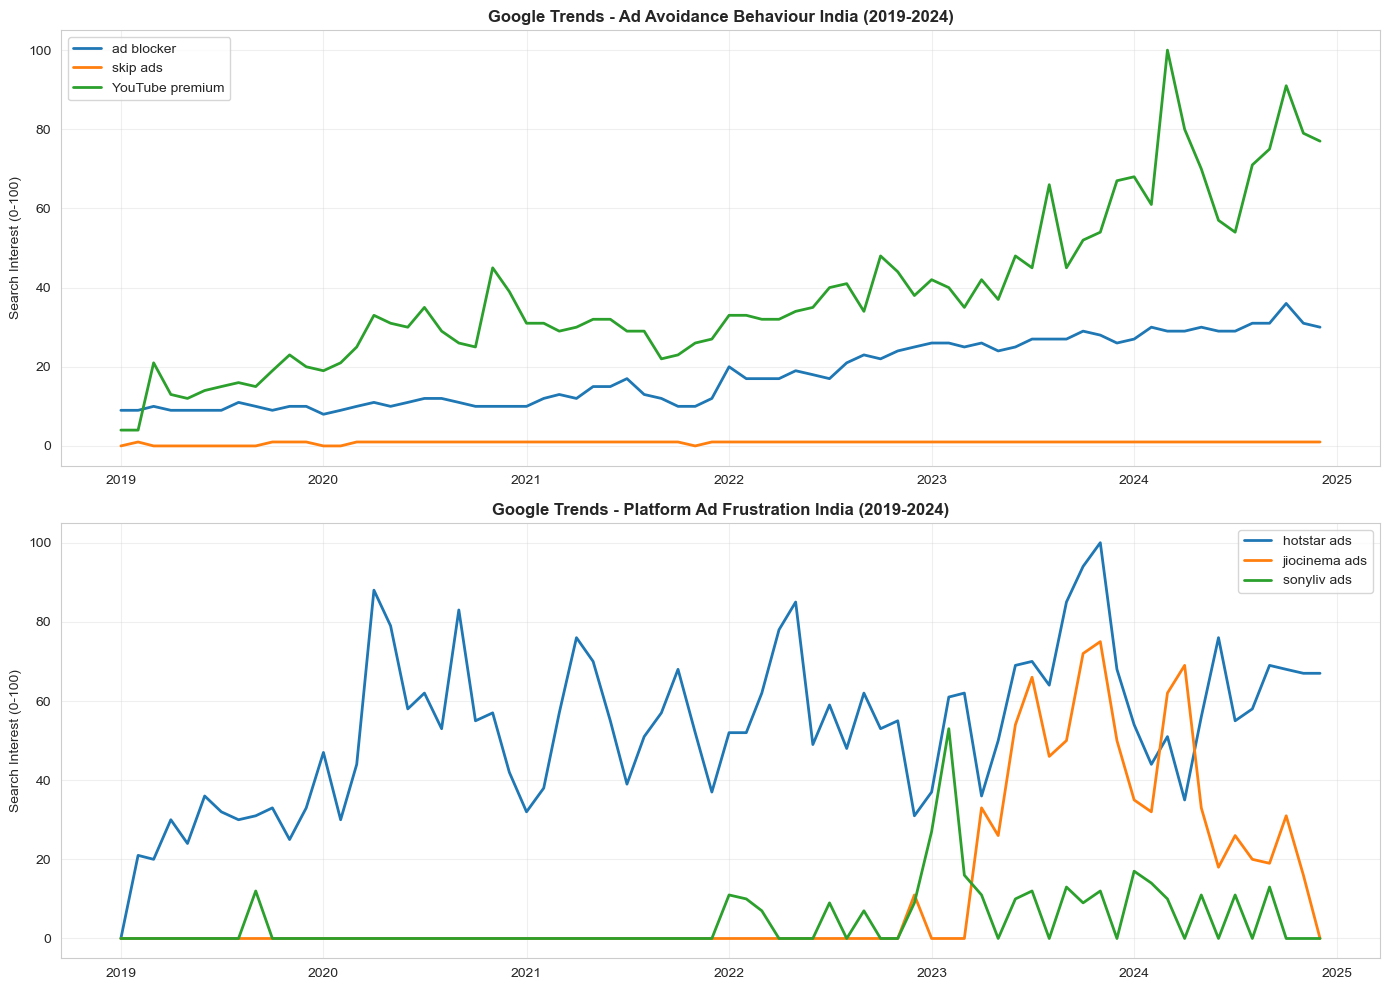

Google Trends chart saved


In [60]:
pytrends = TrendReq(hl='en-IN', tz=330)

keyword_groups = {
    'Ad Avoidance': ['ad blocker', 'skip ads', 'YouTube premium'],
    'Platform Frustration': ['hotstar ads', 'jiocinema ads', 'sonyliv ads'],
}

all_trends = {}

for group_name, keywords in keyword_groups.items():
    print(f"Fetching: {keywords}")
    try:
        pytrends.build_payload(keywords, cat=0,
            timeframe='2019-01-01 2024-12-31', geo='IN')
        df_trend = pytrends.interest_over_time()
        if not df_trend.empty:
            df_trend = df_trend.drop(columns=['isPartial'], errors='ignore')
            all_trends[group_name] = df_trend
            print(f"  Got {len(df_trend)} weeks of data")
        time.sleep(2)
    except Exception as e:
        print(f"  Error: {e}")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

if 'Ad Avoidance' in all_trends:
    df_avoid = all_trends['Ad Avoidance']
    for col in df_avoid.columns:
        axes[0].plot(df_avoid.index, df_avoid[col], linewidth=2, label=col)
    axes[0].set_title('Google Trends - Ad Avoidance Behaviour India (2019-2024)',
        fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Search Interest (0-100)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if 'Platform Frustration' in all_trends:
    df_plat = all_trends['Platform Frustration']
    for col in df_plat.columns:
        axes[1].plot(df_plat.index, df_plat[col], linewidth=2, label=col)
    axes[1].set_title('Google Trends - Platform Ad Frustration India (2019-2024)',
        fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Search Interest (0-100)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/google_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Google Trends chart saved")

## 10. LDA Topic Modelling
Unsupervised discovery of complaint themes from negative reviews.

Running LDA on 4488 negative reviews...
LDA Topics:
Topic 1: 0.034*"watch" + 0.033*"worst" + 0.023*"watching" + 0.021*"channel" + 0.021*"live" + 0.020*"skip" + 0.020*"program" + 0.019*"experience"
Topic 2: 0.048*"video" + 0.026*"videos" + 0.022*"youtube" + 0.019*"annoying" + 0.017*"screen" + 0.009*"watch" + 0.009*"worse" + 0.008*"stop"
Topic 3: 0.039*"subscription" + 0.019*"premium" + 0.018*"service" + 0.014*"customer" + 0.013*"money" + 0.012*"worst" + 0.011*"sony" + 0.011*"live"
Topic 4: 0.038*"watch" + 0.029*"worst" + 0.022*"shows" + 0.022*"download" + 0.020*"internet" + 0.017*"movies" + 0.014*"video" + 0.013*"movie"
Topic 5: 0.034*"subscription" + 0.031*"experience" + 0.029*"watch" + 0.017*"premium" + 0.017*"paying" + 0.015*"content" + 0.015*"watching" + 0.015*"money"
Topic 6: 0.029*"account" + 0.021*"instagram" + 0.019*"tried" + 0.019*"frustrating" + 0.014*"error" + 0.013*"login" + 0.012*"working" + 0.011*"times"
Assigning topics...


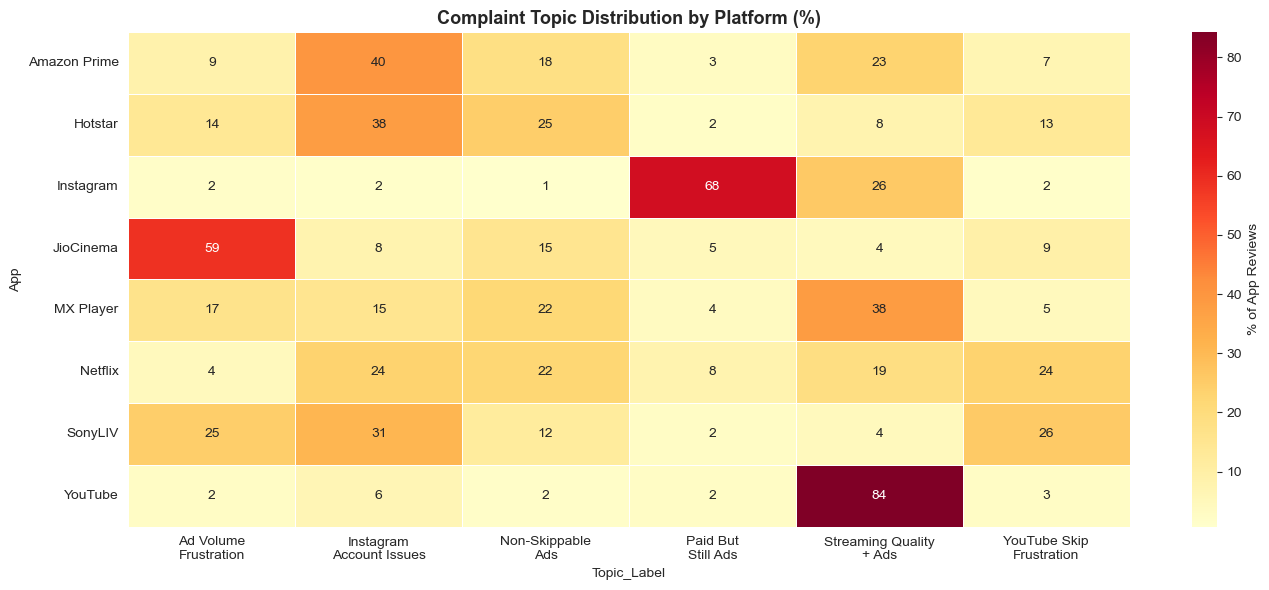

LDA chart saved


In [61]:
negative_reviews = df[df['Sentiment_Label'] == 'Negative']['Review'].tolist()
print(f"Running LDA on {len(negative_reviews)} negative reviews...")

def preprocess(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    custom_stop = STOPWORDS.union({
        'app','use','used','using','good','bad','just','like','get','got',
        'one','also','even','still','time','now','new','dont','cant','will',
        'make','please','update','version','phone','device','need','want',
        'show','open','fix','issue','problem','work','im','ive','its','iam',
        'thats','doesnt','didnt'
    })
    return [t for t in tokens if t not in custom_stop and len(t) > 3]

tokenised = [preprocess(r) for r in negative_reviews]
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=10, no_above=0.4)
corpus = [dictionary.doc2bow(doc) for doc in tokenised]

lda_model = LdaModel(corpus=corpus, id2word=dictionary,
    num_topics=6, random_state=42, passes=15, alpha='auto')

topic_labels = {
    0: 'Ad Volume\nFrustration',
    1: 'Streaming Quality\n+ Ads',
    2: 'YouTube Skip\nFrustration',
    3: 'Non-Skippable\nAds',
    4: 'Instagram\nAccount Issues',
    5: 'Paid But\nStill Ads'
}

print("LDA Topics:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx+1}: {topic}")

def get_dominant_topic(text):
    tokens = preprocess(text)
    bow = dictionary.doc2bow(tokens)
    if not bow: return -1
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

df_neg = df[df['Sentiment_Label'] == 'Negative'].copy()
print("Assigning topics...")
df_neg['Dominant_Topic'] = df_neg['Review'].apply(get_dominant_topic)
df_neg['Topic_Label'] = df_neg['Dominant_Topic'].map(topic_labels)

topic_app = df_neg.groupby(['App','Topic_Label']).size().unstack(fill_value=0)
topic_app_pct = topic_app.div(topic_app.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(topic_app_pct, ax=ax, cmap='YlOrRd', annot=True,
    fmt='.0f', linewidths=0.5, cbar_kws={'label': '% of App Reviews'})
ax.set_title('Complaint Topic Distribution by Platform (%)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()
print("LDA chart saved")

## 11. Literature Review
10 references contextualising this research.

In [62]:
print("""
LITERATURE REVIEW
Indian Digital Advertising Sentiment Analysis

[1] Sundaravel & Elangovan (2020). Emergence of OTT video services in India.
    International Journal of Business Management.
    Context: Documents India OTT market emergence and Jio role in digital adoption.

[2] Chakraborty et al. (2023). Streaming towards innovation: OTT adoption in India.
    Cogent Business & Management, 10(2). DOI: 10.1080/23311975.2023.2283917
    Context: Two-wave India study on OTT adoption barriers.

[3] Verma & Yadav (2023). Consumer Satisfaction Toward OTT Platforms in India.
    Journal of Creative Communications, SAGE. DOI: 10.1177/22786821231161853
    Context: Identifies satisfaction drivers — our findings contradict expectations.

[4] Menon et al. (2021). Willingness to subscribe to OTT platforms in India.
    Telematics and Informatics. DOI: 10.1016/S0160-791X(21)00009-9
    Context: Content and trust drive subscriptions — ads break that trust.

[5] Ormax Media (2024). OTT Audience Report 2024: India reaches 547 million users.
    Context: SVOD declined 2%, AVOD grew 21% — validates our paid platform findings.

[6] Storyboard18 (2025). From Binge to Breaks: Ads redefining OTT in India.
    Context: Subscription fatigue is real — confirms our Finding 2.

[7] Celik et al. (2022). Ad avoidance in digital context: systematic review.
    International Journal of Consumer Studies. DOI: 10.1111/ijcs.12882
    Context: Irrelevance and intrusiveness drive avoidance — matches our LDA topics.

[8] Wang et al. (2022). Consumers perceived risk on advertising avoidance.
    Frontiers in Psychology. DOI: 10.3389/fpsyg.2022.878629
    Context: Negative emotions drive ad avoidance — our Google Trends confirms this.

[9] FICCI & Ernst Young LLP (2024). India Media & Entertainment Report 2024.
    Context: Verified source — digital advertising INR 576B in 2023, 51% of total.

[10] Pitch Madison Advertising (2024). Pitch Madison Advertising Report 2024.
     Context: Verified source — total ADEX 2023 INR 99,038 Crore, digital 40% share.
""")


LITERATURE REVIEW
Indian Digital Advertising Sentiment Analysis

[1] Sundaravel & Elangovan (2020). Emergence of OTT video services in India.
    International Journal of Business Management.
    Context: Documents India OTT market emergence and Jio role in digital adoption.

[2] Chakraborty et al. (2023). Streaming towards innovation: OTT adoption in India.
    Cogent Business & Management, 10(2). DOI: 10.1080/23311975.2023.2283917
    Context: Two-wave India study on OTT adoption barriers.

[3] Verma & Yadav (2023). Consumer Satisfaction Toward OTT Platforms in India.
    Journal of Creative Communications, SAGE. DOI: 10.1177/22786821231161853
    Context: Identifies satisfaction drivers — our findings contradict expectations.

[4] Menon et al. (2021). Willingness to subscribe to OTT platforms in India.
    Telematics and Informatics. DOI: 10.1016/S0160-791X(21)00009-9
    Context: Content and trust drive subscriptions — ads break that trust.

[5] Ormax Media (2024). OTT Audience Re

## 12. Advanced Statistical Analysis
Pearson correlation, sentiment over time, and platform radar chart.

Overall Pearson r=0.3735, p=1.14e-251


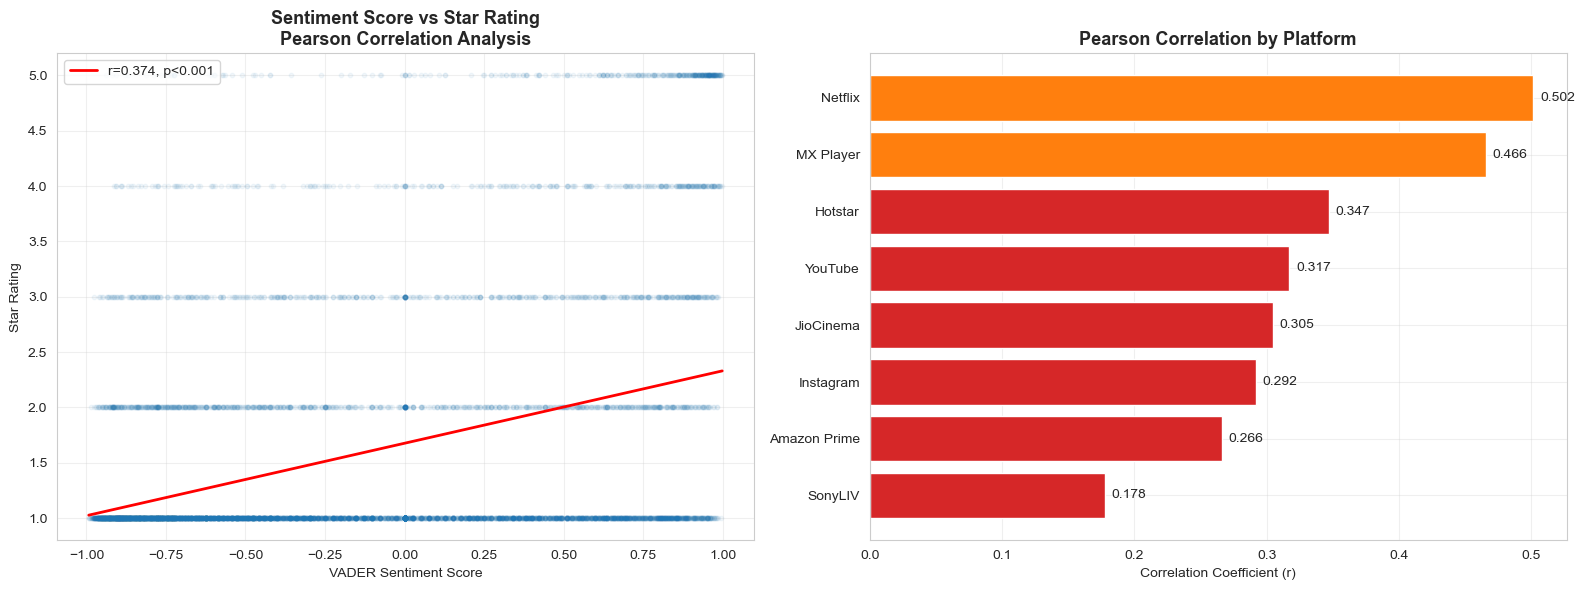

Correlation chart saved


In [63]:
corr, pvalue = stats.pearsonr(df['Sentiment_Score'], df['Rating'])
print(f"Overall Pearson r={corr:.4f}, p={pvalue:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['Sentiment_Score'], df['Rating'],
    alpha=0.05, color='#1f77b4', s=10)
m, b = np.polyfit(df['Sentiment_Score'], df['Rating'], 1)
x_line = np.linspace(df['Sentiment_Score'].min(), df['Sentiment_Score'].max(), 100)
axes[0].plot(x_line, m*x_line+b, color='red', linewidth=2,
    label=f'r={corr:.3f}, p<0.001')
axes[0].set_title('Sentiment Score vs Star Rating\nPearson Correlation Analysis',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('VADER Sentiment Score')
axes[0].set_ylabel('Star Rating')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

apps_list = []
corrs_list = []
for app in df['App'].unique():
    app_df = df[df['App'] == app]
    r, p = stats.pearsonr(app_df['Sentiment_Score'], app_df['Rating'])
    apps_list.append(app)
    corrs_list.append(r)

sorted_pairs = sorted(zip(corrs_list, apps_list))
corrs_s, apps_s = zip(*sorted_pairs)
colors = ['#d62728' if c < 0.4 else '#ff7f0e' if c < 0.6 else '#2ca02c'
    for c in corrs_s]
axes[1].barh(apps_s, corrs_s, color=colors, edgecolor='white')
axes[1].set_title('Pearson Correlation by Platform',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient (r)')
for i, (app, val) in enumerate(zip(apps_s, corrs_s)):
    axes[1].text(val+0.005, i, f'{val:.3f}', va='center', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation chart saved")

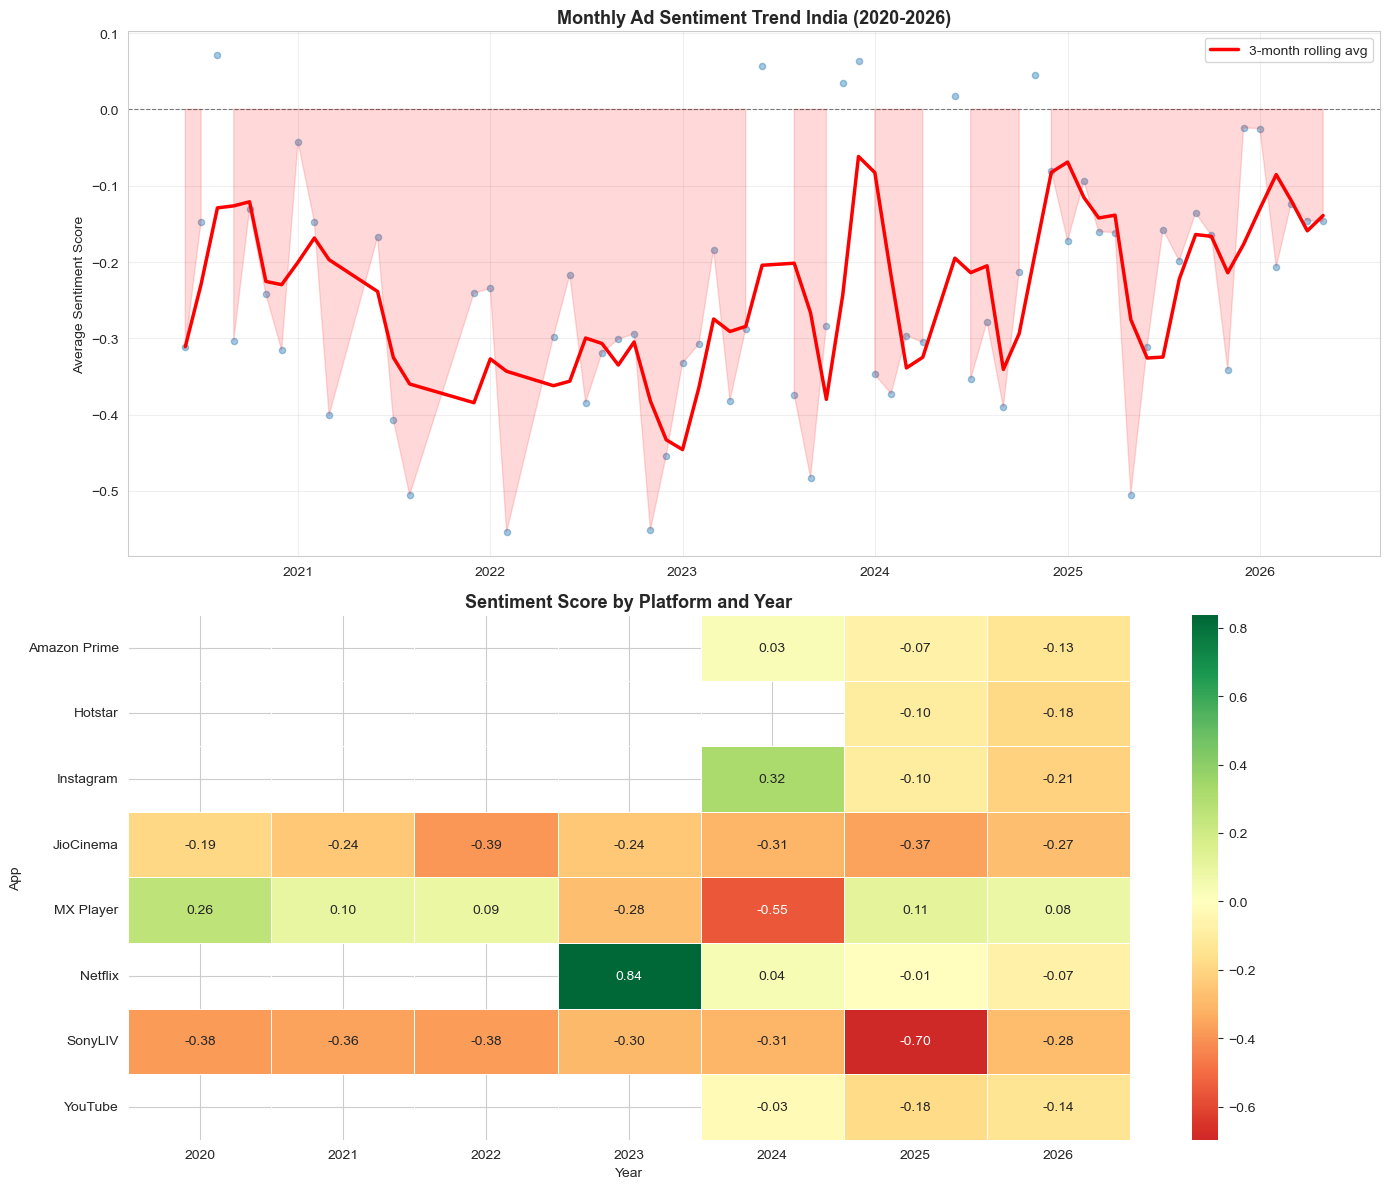

Sentiment trend chart saved


In [64]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
df['YearMonth'] = pd.to_datetime(df['Date']).dt.to_period('M')
df_time = df[df['Year'] >= 2020].copy()

monthly_sentiment = df_time.groupby('YearMonth')['Sentiment_Score'].agg(
    ['mean','count']).reset_index()
monthly_sentiment['YearMonth_dt'] = monthly_sentiment['YearMonth'].dt.to_timestamp()
monthly_sentiment = monthly_sentiment[monthly_sentiment['count'] >= 10]

yearly_app = df_time.groupby(['Year','App'])['Sentiment_Score'].mean().unstack()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].scatter(monthly_sentiment['YearMonth_dt'],
    monthly_sentiment['mean'], alpha=0.4, color='#1f77b4', s=20)
rolling = monthly_sentiment.set_index('YearMonth_dt')['mean'].rolling(3, min_periods=1).mean()
axes[0].plot(rolling.index, rolling.values, color='red', linewidth=2.5, label='3-month rolling avg')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].fill_between(monthly_sentiment['YearMonth_dt'], monthly_sentiment['mean'], 0,
    where=monthly_sentiment['mean'] < 0, alpha=0.15, color='red')
axes[0].set_title('Monthly Ad Sentiment Trend India (2020-2026)',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Sentiment Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.heatmap(yearly_app.T, ax=axes[1], cmap='RdYlGn', center=0,
    annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Sentiment Score by Platform and Year',
    fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sentiment trend chart saved")

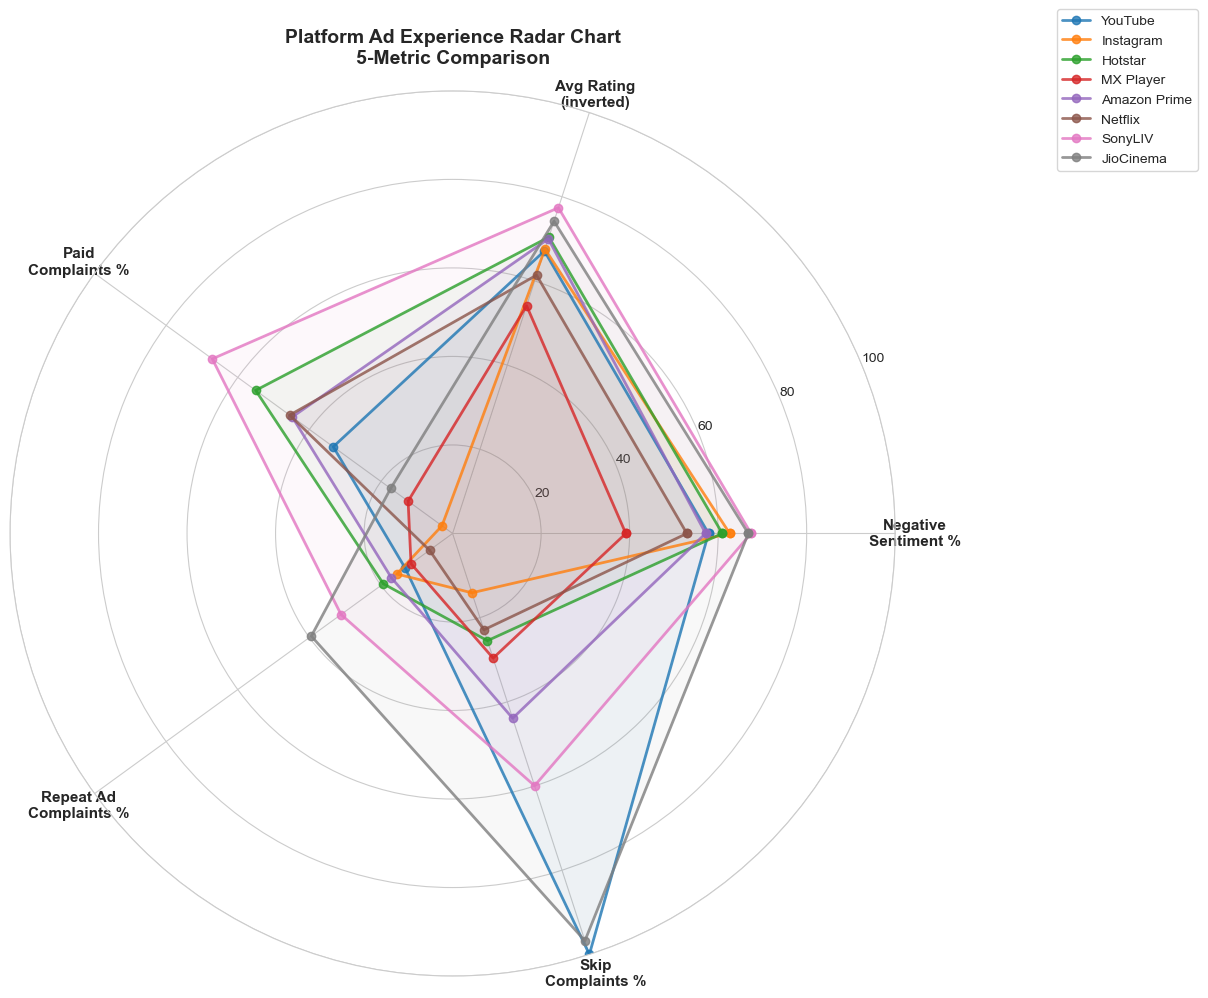

Radar chart saved


In [65]:
platforms_r = ['YouTube','Instagram','Hotstar','MX Player',
    'Amazon Prime','Netflix','SonyLIV','JioCinema']

metrics = {}
for app in platforms_r:
    app_df = df[df['App'] == app]
    neg_pct = (app_df['Sentiment_Label'] == 'Negative').mean() * 100
    avg_rating = app_df['Rating'].mean()
    paid = app_df['Review'].str.lower().str.contains(
        'paid|premium|subscription|money').mean() * 100
    repeat = app_df['Review'].str.lower().str.contains(
        'repeat|same ad|again and again').mean() * 100 * 5
    skip = app_df['Review'].str.lower().str.contains(
        'skip|cannot skip|cant skip').mean() * 100 * 5
    metrics[app] = {
        'Negative\nSentiment %': neg_pct,
        'Avg Rating\n(inverted)': (5-avg_rating)*20,
        'Paid\nComplaints %': paid,
        'Repeat Ad\nComplaints %': repeat,
        'Skip\nComplaints %': skip
    }

categories = list(list(metrics.values())[0].keys())
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
    '#9467bd','#8c564b','#e377c2','#7f7f7f']

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

for i, (app, vals) in enumerate(metrics.items()):
    values = [min(v, 100) for v in vals.values()]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
        color=colors[i], label=app, alpha=0.8)
    ax.fill(angles, values, alpha=0.05, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Platform Ad Experience Radar Chart\n5-Metric Comparison',
    fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved")

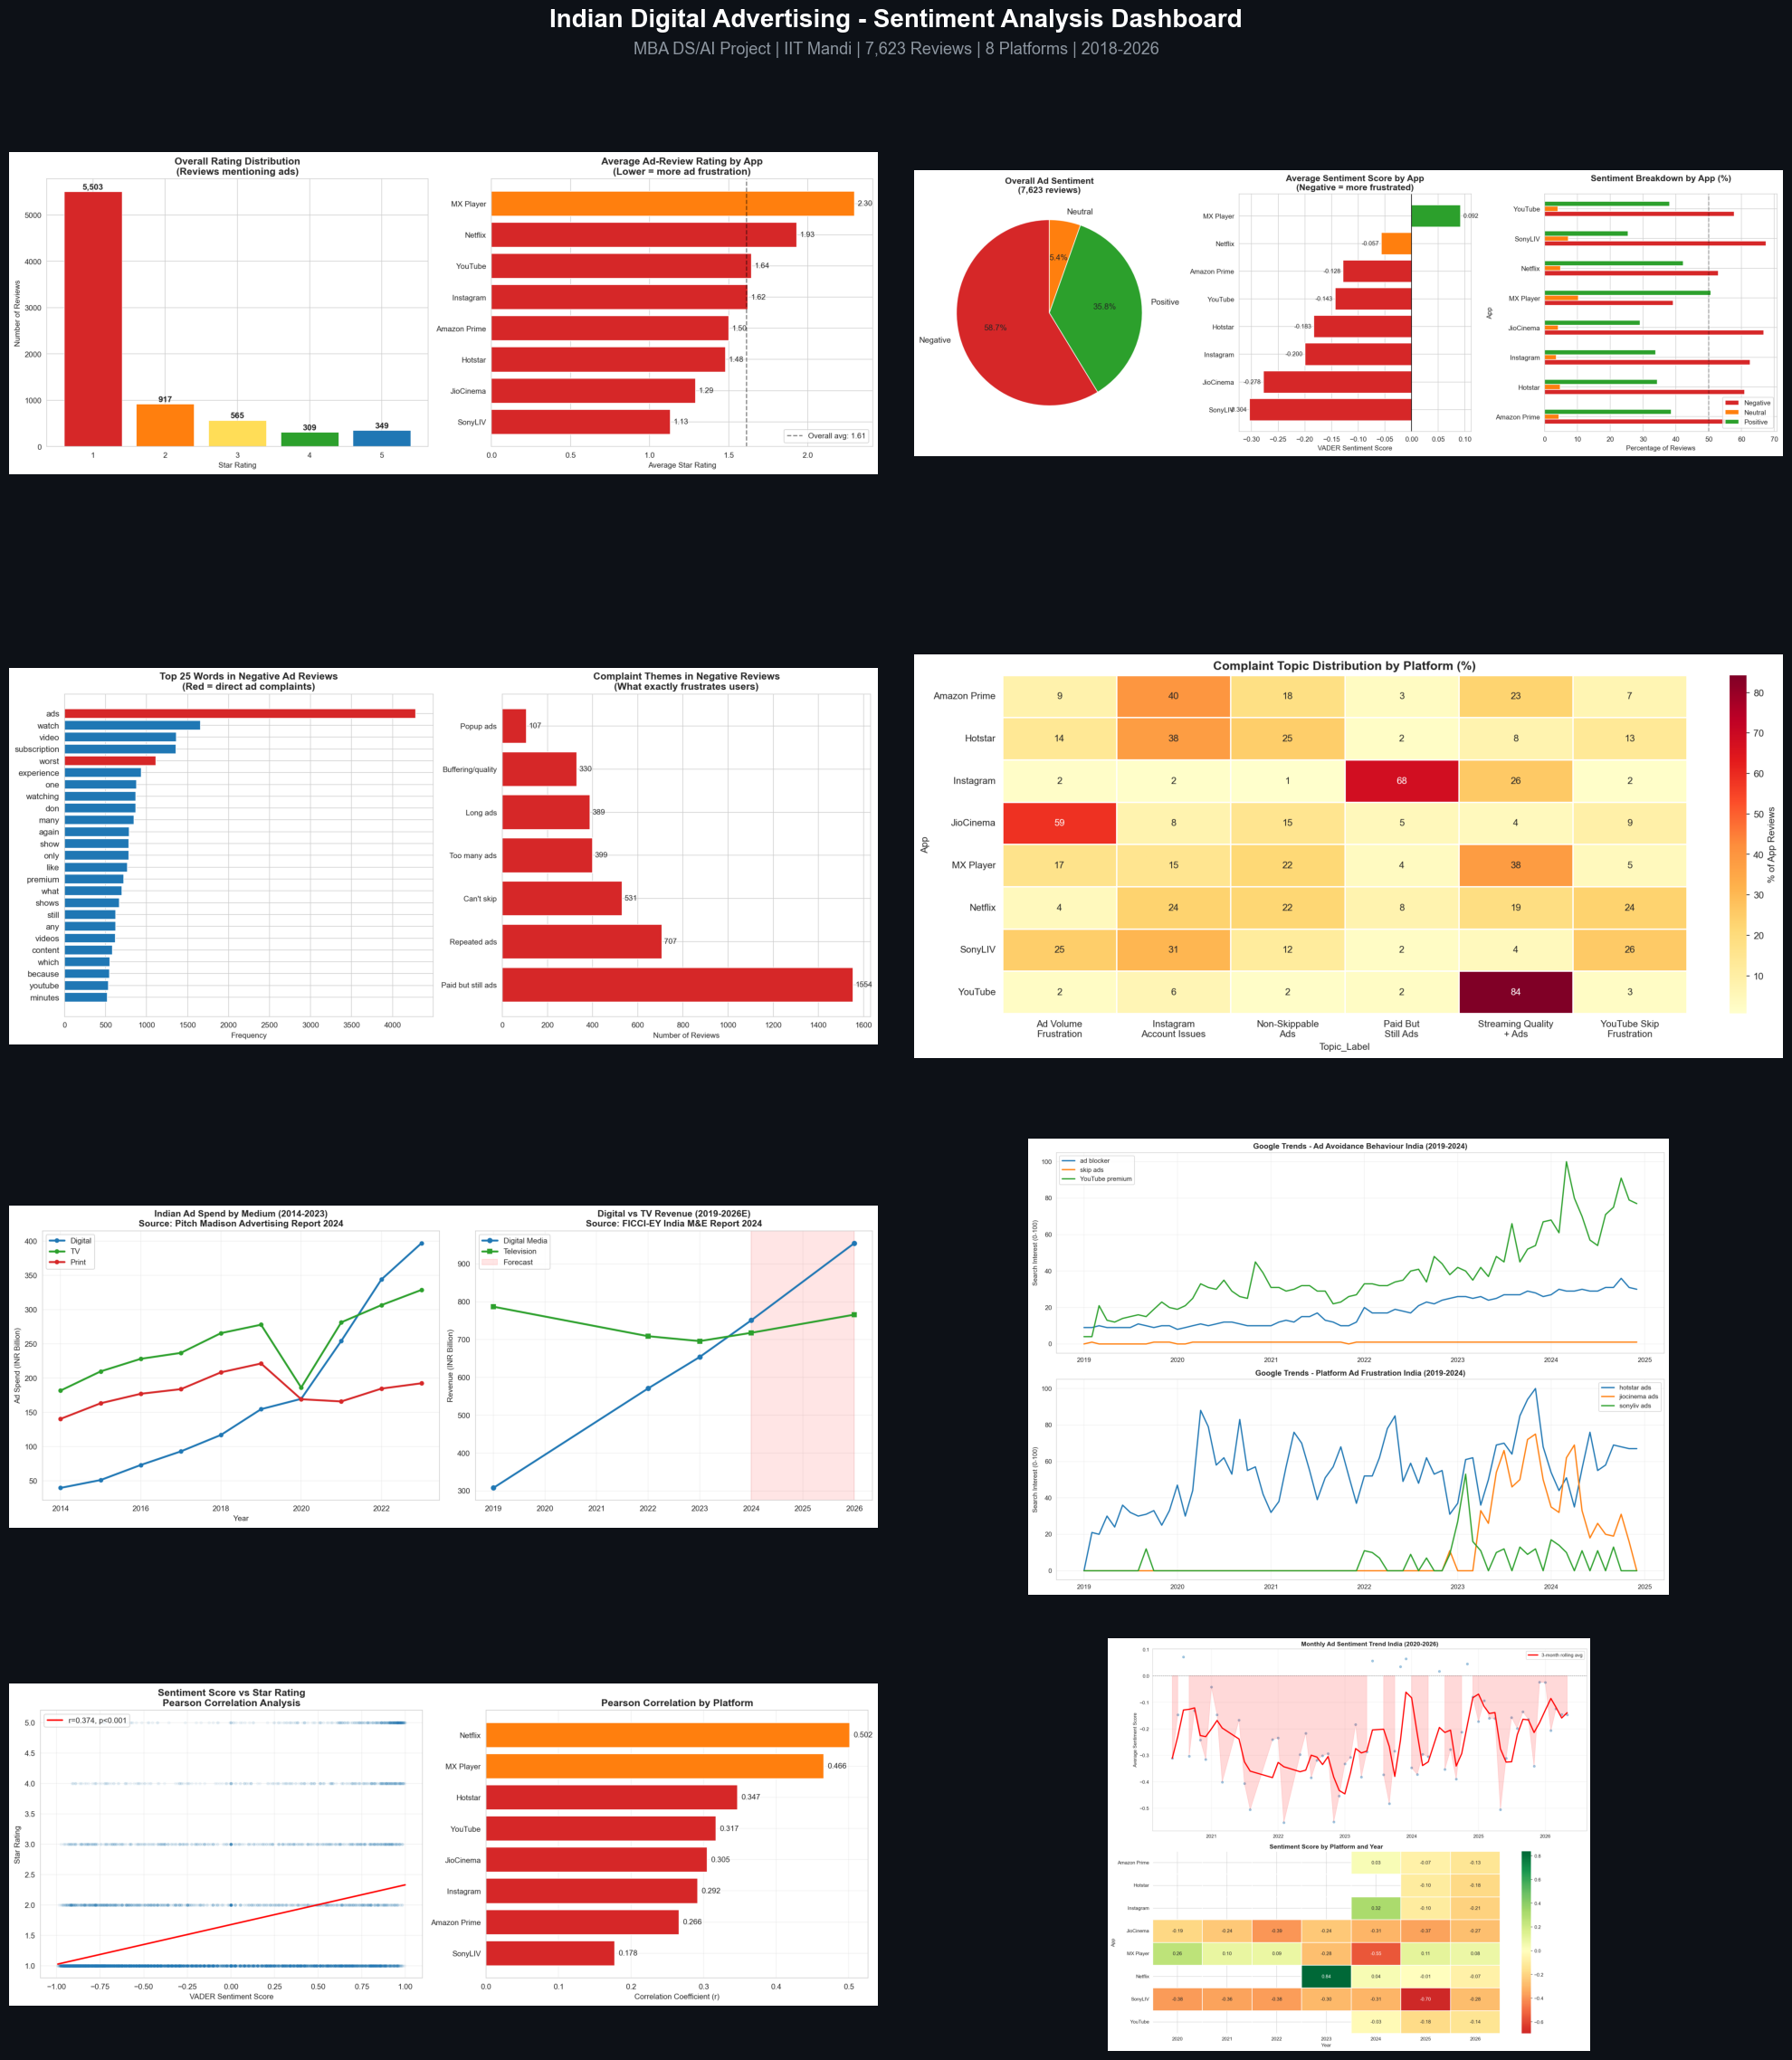

Master dashboard saved


In [66]:
from matplotlib.image import imread

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0d1117')
fig.text(0.5, 0.98,
    'Indian Digital Advertising - Sentiment Analysis Dashboard',
    ha='center', va='top', fontsize=20, fontweight='bold', color='white')
fig.text(0.5, 0.965,
    'MBA DS/AI Project | IIT Mandi | 7,623 Reviews | 8 Platforms | 2018-2026',
    ha='center', va='top', fontsize=13, color='#8b949e')

base = '/Users/abhishekanil/Desktop/indian_ad_sentiment_analysis/outputs/'
charts = [
    ('rating_distribution.png',     (0.01, 0.72, 0.48, 0.24)),
    ('sentiment_analysis.png',      (0.51, 0.72, 0.48, 0.24)),
    ('keyword_analysis.png',        (0.01, 0.48, 0.48, 0.22)),
    ('lda_topics.png',              (0.51, 0.48, 0.48, 0.22)),
    ('verified_industry_data.png',  (0.01, 0.25, 0.48, 0.21)),
    ('google_trends.png',           (0.51, 0.25, 0.48, 0.21)),
    ('correlation_analysis.png',    (0.01, 0.04, 0.48, 0.19)),
    ('sentiment_over_time.png',     (0.51, 0.04, 0.48, 0.19)),
]

for filename, (x, y, w, h) in charts:
    path = base + filename
    if os.path.exists(path):
        ax = fig.add_axes([x, y, w, h])
        ax.imshow(imread(path))
        ax.axis('off')

plt.savefig('../outputs/MASTER_DASHBOARD.png',
    dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Master dashboard saved")